In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def aplicar_filtro_preto_e_branco(img):
    cinza = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(cinza, cv2.COLOR_GRAY2RGB)

def aplicar_filtro_brilho(img, valor=50):
    return cv2.convertScaleAbs(img, alpha=1, beta=valor)

def aplicar_filtro_sepia(img):
    filtro_sepia = np.array([
        [0.393,0.769,0.189],
        [0.349, 0.686, 0.168],
        [0.272,0.534,0.131]
    ])

    img_sepia = cv2.transform(img, filtro_sepia)
    return np.clip(img_sepia, 0, 255).astype(np.uint8)

def aplicar_filtro_vintage(img):
    blur=cv2.GaussianBlur(img, (21,21),0)
    alpha=0.7
    return cv2.addWeighted(blur, alpha,img,1-alpha,0)

def aplicar_filtro_desenho(img):
    cinza = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    inv = 255 - cinza
    blur = cv2.GaussianBlur(inv, (21,21), 0)
    contorno = cv2.divide(cinza, 255-blur,scale=256)
    return cv2.cvtColor(contorno, cv2.COLOR_GRAY2RGB)

def mostrar_imagens(nome_filtro, imagem_filtrada,imagem_original):
    fig, axs = plt.subplots(1,2,figsize=(15,4))
    axs[0].imshow(imagem_original)
    axs[0].set_title('Imagem Original')
    axs[0].axis('off')
    axs[1].imshow(imagem_filtrada)
    axs[1].set_title(f'Filtro {nome_filtro}')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

In [5]:
def menu_filtro(img):
    while True:
        print("\n========== MENU DE FILTROS ==========")
        print("1 - filtro preto e branco")
        print("2 - filtro de brilho (+50)")
        print("3 - filtro sépia")
        print("4 - filtro vintage")
        print("5 - filtro desenho lápis")
        print("0 - Sair")

        escolha = input("Escolha uma opção: ")

        if escolha == '1':
            resultado = aplicar_filtro_preto_e_branco(img)
            mostrar_imagens("Preto Branco", resultado, img)
        elif escolha == '2':
            resultado = aplicar_filtro_brilho(img)
            mostrar_imagens("Brilho", resultado, img)
        elif escolha == '3':
            resultado = aplicar_filtro_sepia(img)
            mostrar_imagens("Sepia", resultado, img)
        elif escolha == '4':
            resultado = aplicar_filtro_vintage(img)
            mostrar_imagens("Vintage", resultado, img)
        elif escolha == '5':
            resultado = aplicar_filtro_desenho(img)
            mostrar_imagens("Desenho", resultado, img)
        elif escolha == '0':
            print("Encerrando")
            break
        else:
            print("Opção Inválida")


========== MENU DE FILTROS ==========
1 - filtro preto e branco
2 - filtro de brilho (+50)
3 - filtro sépia
4 - filtro vintage
5 - filtro desenho lápis
0 - Sair


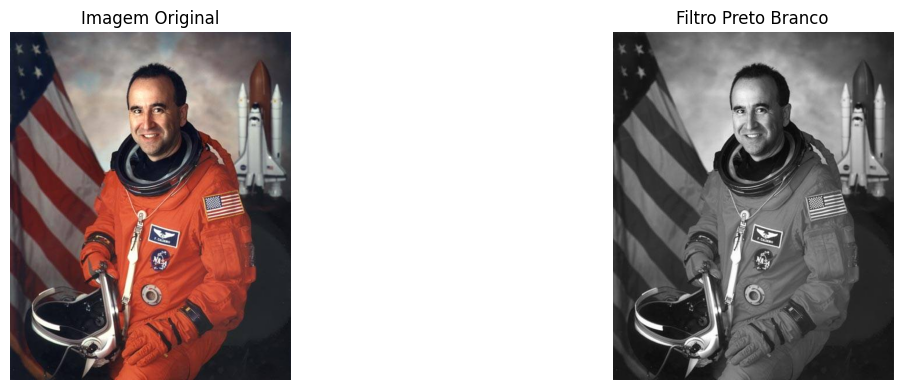


========== MENU DE FILTROS ==========
1 - filtro preto e branco
2 - filtro de brilho (+50)
3 - filtro sépia
4 - filtro vintage
5 - filtro desenho lápis
0 - Sair


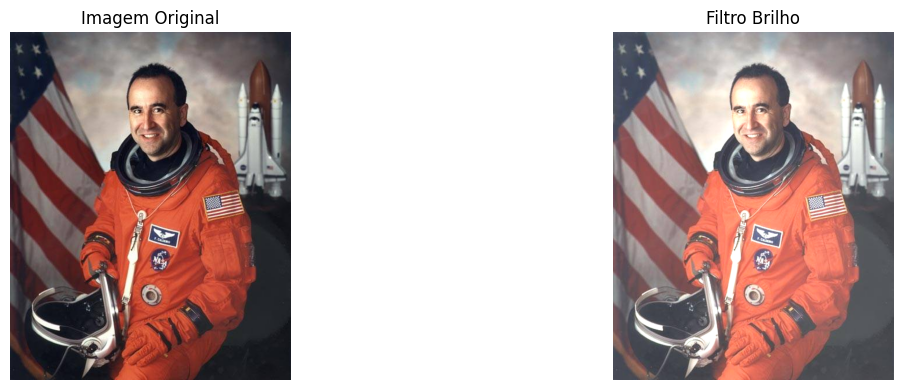


========== MENU DE FILTROS ==========
1 - filtro preto e branco
2 - filtro de brilho (+50)
3 - filtro sépia
4 - filtro vintage
5 - filtro desenho lápis
0 - Sair


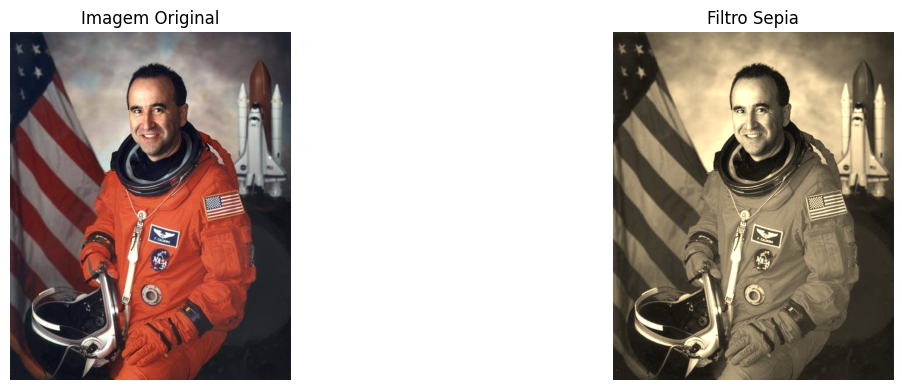


========== MENU DE FILTROS ==========
1 - filtro preto e branco
2 - filtro de brilho (+50)
3 - filtro sépia
4 - filtro vintage
5 - filtro desenho lápis
0 - Sair


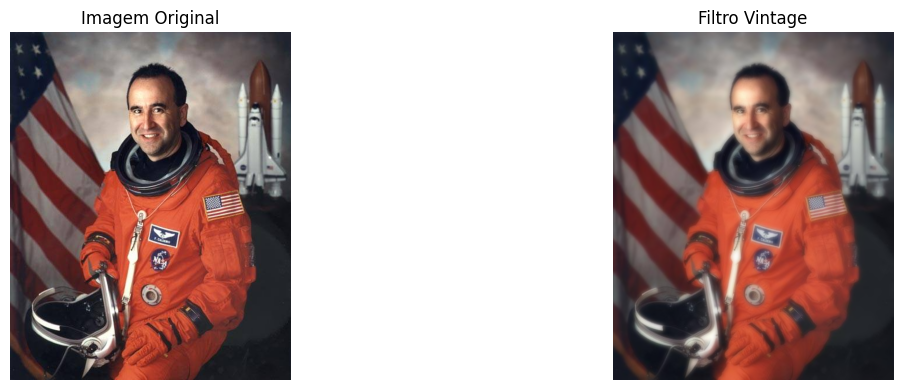


========== MENU DE FILTROS ==========
1 - filtro preto e branco
2 - filtro de brilho (+50)
3 - filtro sépia
4 - filtro vintage
5 - filtro desenho lápis
0 - Sair


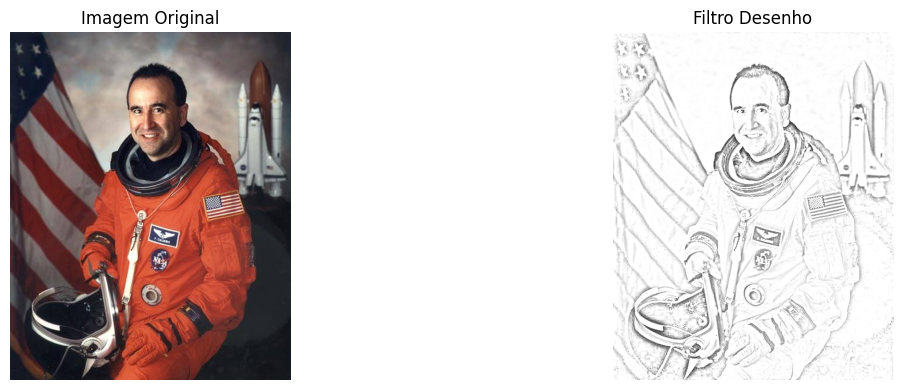


========== MENU DE FILTROS ==========
1 - filtro preto e branco
2 - filtro de brilho (+50)
3 - filtro sépia
4 - filtro vintage
5 - filtro desenho lápis
0 - Sair
Encerrando


In [6]:
img_original = cv2.imread('../fundamentals/data/astronauta.jpg')

if img_original is None:
    print("Erro ao carrgar a imagem")
else:
    img = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    menu_filtro(img)